# Final Exam Project
## **AI-Driven Smart Logistics & Supply Chain Intelligence System**

### Dataset: Supply Chain Analysis Dataset
### Group Members: Sultan Mykhtybayev, Alimzhan Tursynov

INSTALL AND IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


LOAD DATASET

In [4]:
file_path = "supply_chain_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Shape of dataset:", df.shape)

display(df.head())
display(df.info())
display(df.describe())

Dataset loaded successfully
Shape of dataset: (100, 24)


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

None

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


BASIC DATA UNDERSTANDING

In [5]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Column names:
['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']

Missing values:


,0
Product type,0
SKU,0
Price,0
Availability,0
Number of products sold,0
Revenue generated,0
Customer demographics,0
Stock levels,0
Lead times,0
Order quantities,0



Duplicate rows:
0


TASK 1 — DATA CLEANING & PREPARATION

In [6]:
print("\nTASK 1 — DATA CLEANING & PREPARATION")

# Remove duplicate records
df = df.drop_duplicates()

# Clean column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("-", "_")
df.columns = df.columns.str.replace("/", "_")

print("Cleaned column names:")
print(df.columns.tolist())

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("\nMissing values after cleaning:")
display(df.isnull().sum())

# Convert object columns to string
object_cols = df.select_dtypes(include=["object"]).columns
for col in object_cols:
    df[col] = df[col].astype(str)

# Create calculated columns

# Profit
if "Revenue_generated" in df.columns and "Manufacturing_costs" in df.columns and "Shipping_costs" in df.columns:
    df["Profit"] = df["Revenue_generated"] - df["Manufacturing_costs"] - df["Shipping_costs"]
elif "Revenue_generated" in df.columns and "Manufacturing_costs" in df.columns:
    df["Profit"] = df["Revenue_generated"] - df["Manufacturing_costs"]
else:
    df["Profit"] = 0

# Total cost
if "Manufacturing_costs" in df.columns and "Shipping_costs" in df.columns:
    df["Total_Cost"] = df["Manufacturing_costs"] + df["Shipping_costs"]
elif "Manufacturing_costs" in df.columns:
    df["Total_Cost"] = df["Manufacturing_costs"]
else:
    df["Total_Cost"] = 0

# Profit margin
if "Revenue_generated" in df.columns:
    df["Profit_Margin"] = df["Profit"] / df["Revenue_generated"].replace(0, np.nan)
    df["Profit_Margin"] = df["Profit_Margin"].fillna(0)
else:
    df["Profit_Margin"] = 0

# Delivery delay target
if "Shipping_times" in df.columns:
    delay_limit = df["Shipping_times"].median()
    df["Delay_Status"] = np.where(df["Shipping_times"] > delay_limit, 1, 0)
else:
    df["Delay_Status"] = 0

# Inventory status
if "Stock_levels" in df.columns and "Order_quantities" in df.columns:
    df["Inventory_Ratio"] = df["Stock_levels"] / df["Order_quantities"].replace(0, np.nan)
    df["Inventory_Ratio"] = df["Inventory_Ratio"].fillna(0)

    conditions = [
        df["Inventory_Ratio"] < 0.8,
        df["Inventory_Ratio"] > 2.0
    ]

    choices = ["Understock", "Overstock"]

    df["Inventory_Status"] = np.select(conditions, choices, default="Normal")
else:
    df["Inventory_Ratio"] = 0
    df["Inventory_Status"] = "Unknown"

# Demand category
if "Number_of_products_sold" in df.columns:
    df["Demand_Level"] = pd.qcut(
        df["Number_of_products_sold"],
        q=3,
        labels=["Low Demand", "Medium Demand", "High Demand"]
    )
else:
    df["Demand_Level"] = "Unknown"

# Supplier reliability score
if "Lead_time" in df.columns and "Defect_rates" in df.columns:
    df["Supplier_Risk_Score"] = df["Lead_time"] + df["Defect_rates"]
else:
    df["Supplier_Risk_Score"] = 0

# Transportation efficiency
if "Shipping_costs" in df.columns and "Shipping_times" in df.columns:
    df["Transport_Efficiency"] = df["Shipping_costs"] / df["Shipping_times"].replace(0, np.nan)
    df["Transport_Efficiency"] = df["Transport_Efficiency"].fillna(0)
else:
    df["Transport_Efficiency"] = 0

# Create artificial monthly date column for forecasting
# This dataset does not contain a real date column, so we create a monthly timeline for analysis.
df = df.reset_index(drop=True)
df["Month_Number"] = (df.index % 12) + 1
df["Date"] = pd.date_range(start="2021-01-01", periods=len(df), freq="M")

print("\nFinal cleaned dataset:")
display(df.head())

print("\nFinal dataset shape:", df.shape)


# Save cleaned data
df.to_csv("cleaned_supply_chain_data.csv", index=False)
print("Cleaned dataset saved as cleaned_supply_chain_data.csv")


TASK 1 — DATA CLEANING & PREPARATION
Cleaned column names:
['Product_type', 'SKU', 'Price', 'Availability', 'Number_of_products_sold', 'Revenue_generated', 'Customer_demographics', 'Stock_levels', 'Lead_times', 'Order_quantities', 'Shipping_times', 'Shipping_carriers', 'Shipping_costs', 'Supplier_name', 'Location', 'Lead_time', 'Production_volumes', 'Manufacturing_lead_time', 'Manufacturing_costs', 'Inspection_results', 'Defect_rates', 'Transportation_modes', 'Routes', 'Costs']

Missing values after cleaning:


,0
Product_type,0
SKU,0
Price,0
Availability,0
Number_of_products_sold,0
Revenue_generated,0
Customer_demographics,0
Stock_levels,0
Lead_times,0
Order_quantities,0



Final cleaned dataset:


,Product_type,SKU,Price,Availability,Number_of_products_sold,Revenue_generated,Customer_demographics,Stock_levels,Lead_times,Order_quantities,...,Total_Cost,Profit_Margin,Delay_Status,Inventory_Ratio,Inventory_Status,Demand_Level,Supplier_Risk_Score,Transport_Efficiency,Month_Number,Date
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,49.236451,0.994316,0,0.604167,Understock,High Demand,29.226410,0.739143,1,2021-01-31
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,43.333344,0.994192,0,1.432432,Normal,High Demand,27.854068,4.858287,2,2021-02-28
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,38.742499,0.995955,0,0.011364,Understock,Low Demand,16.580593,4.027240,3,2021-03-31
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,37.354310,0.995191,0,0.389831,Understock,Low Demand,28.746649,0.288261,4,2021-04-30
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,95.955709,0.964282,1,0.089286,Understock,High Demand,8.145580,0.486318,5,2021-05-31



Final dataset shape: (100, 35)
Cleaned dataset saved as cleaned_supply_chain_data.csv


TASK 2 — EXPLORATORY DATA ANALYSIS

In [7]:
print("\nTASK 2 — EXPLORATORY DATA ANALYSIS")

# Numeric and categorical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)


TASK 2 — EXPLORATORY DATA ANALYSIS
Numeric columns:
['Price', 'Availability', 'Number_of_products_sold', 'Revenue_generated', 'Stock_levels', 'Lead_times', 'Order_quantities', 'Shipping_times', 'Shipping_costs', 'Lead_time', 'Production_volumes', 'Manufacturing_lead_time', 'Manufacturing_costs', 'Defect_rates', 'Costs', 'Profit', 'Total_Cost', 'Profit_Margin', 'Delay_Status', 'Inventory_Ratio', 'Supplier_Risk_Score', 'Transport_Efficiency', 'Month_Number']

Categorical columns:
['Product_type', 'SKU', 'Customer_demographics', 'Shipping_carriers', 'Supplier_name', 'Location', 'Inspection_results', 'Transportation_modes', 'Routes', 'Inventory_Status', 'Demand_Level']


2.1 Total Revenue by Product Type

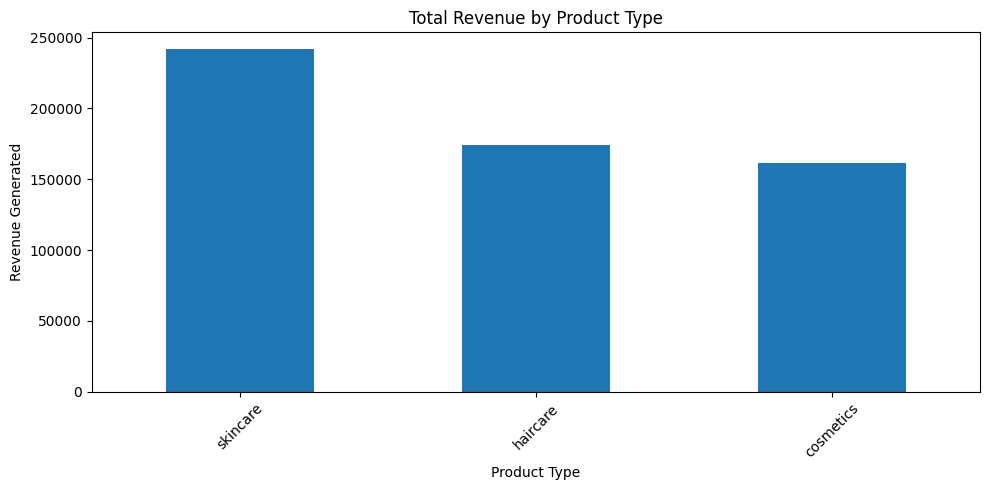

,Revenue_generated
Product_type,
skincare,241628.162133
haircare,174455.390605
cosmetics,161521.265999


In [8]:
if "Product_type" in df.columns and "Revenue_generated" in df.columns:
    product_revenue = df.groupby("Product_type")["Revenue_generated"].sum().sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    product_revenue.plot(kind="bar")
    plt.title("Total Revenue by Product Type")
    plt.xlabel("Product Type")
    plt.ylabel("Revenue Generated")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(product_revenue)

2.2 Sales Trend Over Time

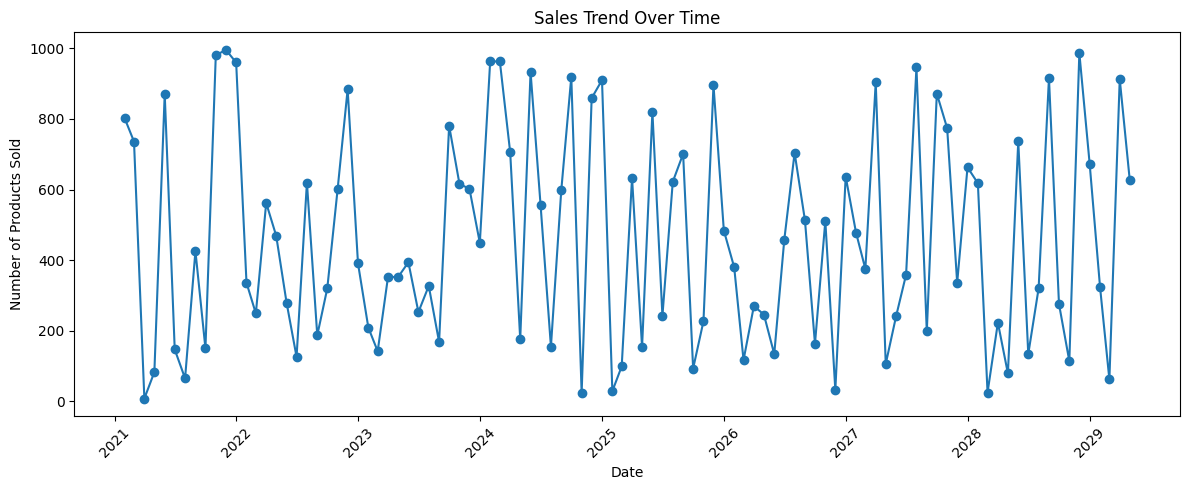

,Number_of_products_sold
Date,
2021-01-31,802
2021-02-28,736
2021-03-31,8
2021-04-30,83
2021-05-31,871


In [9]:
if "Number_of_products_sold" in df.columns:
    monthly_sales = df.groupby("Date")["Number_of_products_sold"].sum()

    plt.figure(figsize=(12, 5))
    plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
    plt.title("Sales Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Number of Products Sold")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(monthly_sales.head())

2.3 Seasonal Demand Pattern

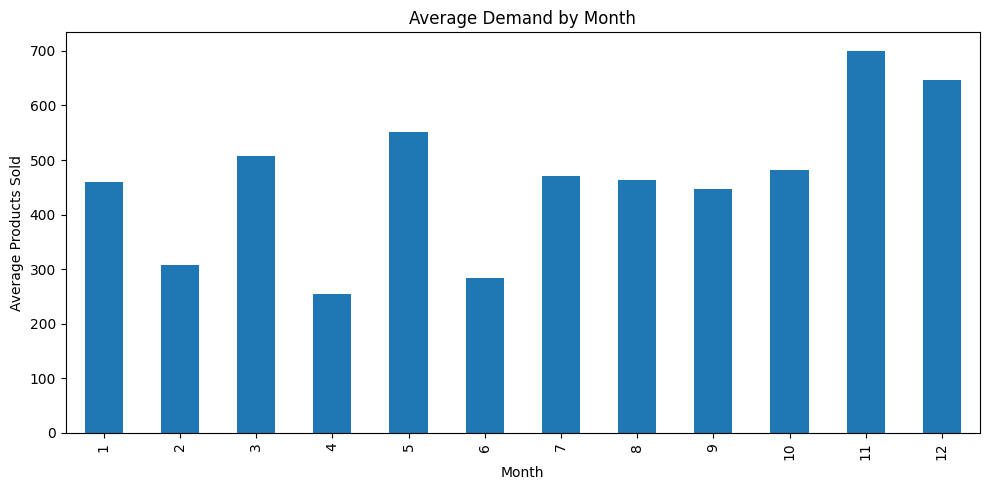

,Number_of_products_sold
Month_Number,
1,459.888889
2,307.555556
3,507.888889
4,254.666667
5,551.250000
6,284.250000
7,469.875000
8,463.375000
9,446.750000


In [10]:
if "Number_of_products_sold" in df.columns:
    seasonality = df.groupby("Month_Number")["Number_of_products_sold"].mean()

    plt.figure(figsize=(10, 5))
    seasonality.plot(kind="bar")
    plt.title("Average Demand by Month")
    plt.xlabel("Month")
    plt.ylabel("Average Products Sold")
    plt.tight_layout()
    plt.show()

    display(seasonality)

2.4 Delivery Performance

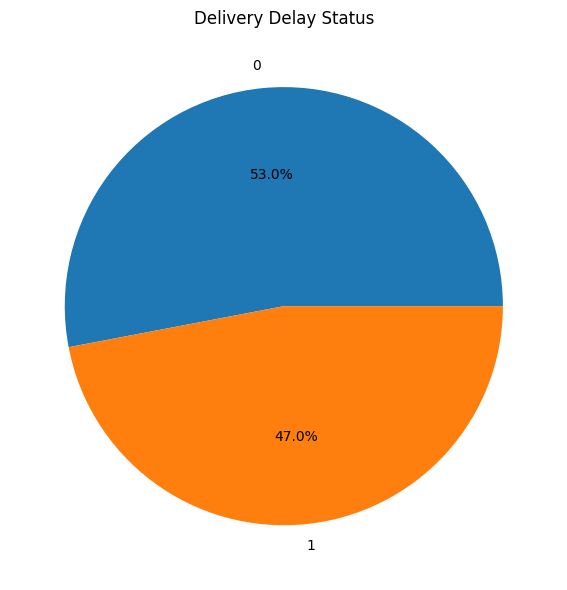

,count
Delay_Status,
0,53
1,47


In [11]:
if "Delay_Status" in df.columns:
    delay_counts = df["Delay_Status"].value_counts()

    plt.figure(figsize=(6, 6))
    delay_counts.plot(kind="pie", autopct="%1.1f%%")
    plt.title("Delivery Delay Status")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    display(delay_counts)

2.5 Shipping Costs by Carrier

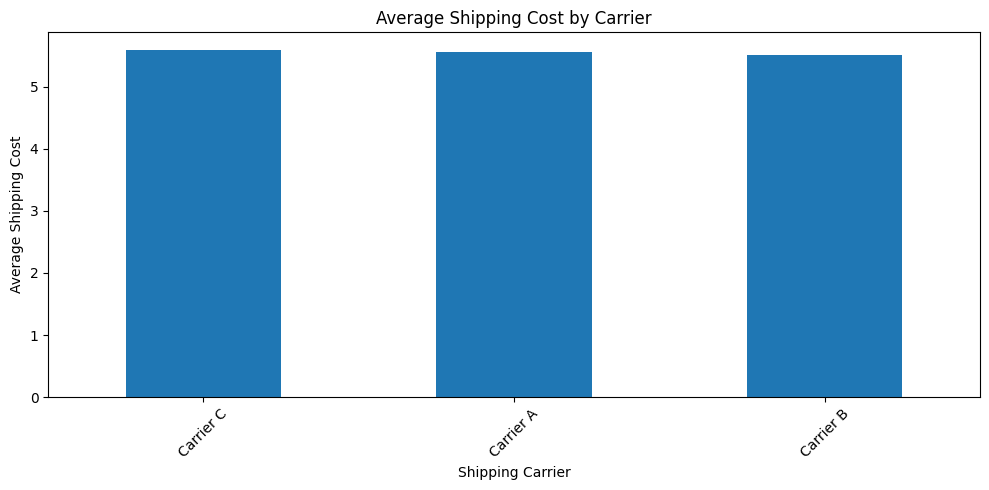

,Shipping_costs
Shipping_carriers,
Carrier C,5.599292
Carrier A,5.554923
Carrier B,5.509247


In [12]:
if "Shipping_carriers" in df.columns and "Shipping_costs" in df.columns:
    carrier_cost = df.groupby("Shipping_carriers")["Shipping_costs"].mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    carrier_cost.plot(kind="bar")
    plt.title("Average Shipping Cost by Carrier")
    plt.xlabel("Shipping Carrier")
    plt.ylabel("Average Shipping Cost")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(carrier_cost)

2.6 Inventory Status

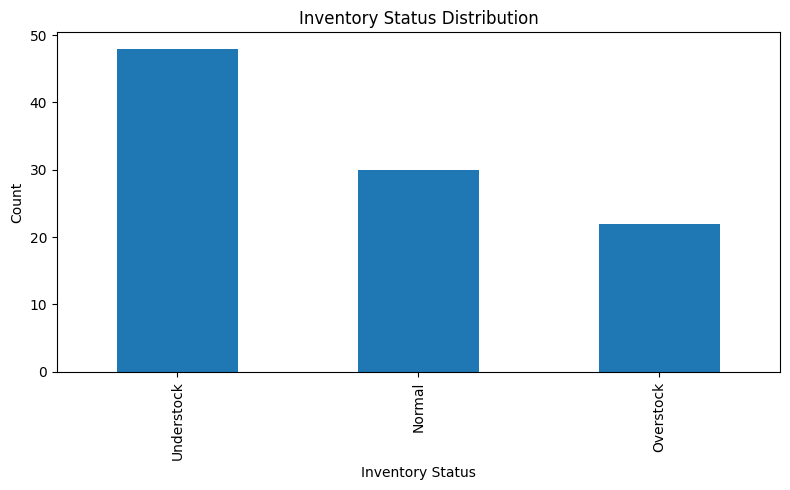

,count
Inventory_Status,
Understock,48
Normal,30
Overstock,22


In [13]:
if "Inventory_Status" in df.columns:
    inventory_counts = df["Inventory_Status"].value_counts()

    plt.figure(figsize=(8, 5))
    inventory_counts.plot(kind="bar")
    plt.title("Inventory Status Distribution")
    plt.xlabel("Inventory Status")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    display(inventory_counts)

2.7 Supplier Behavior

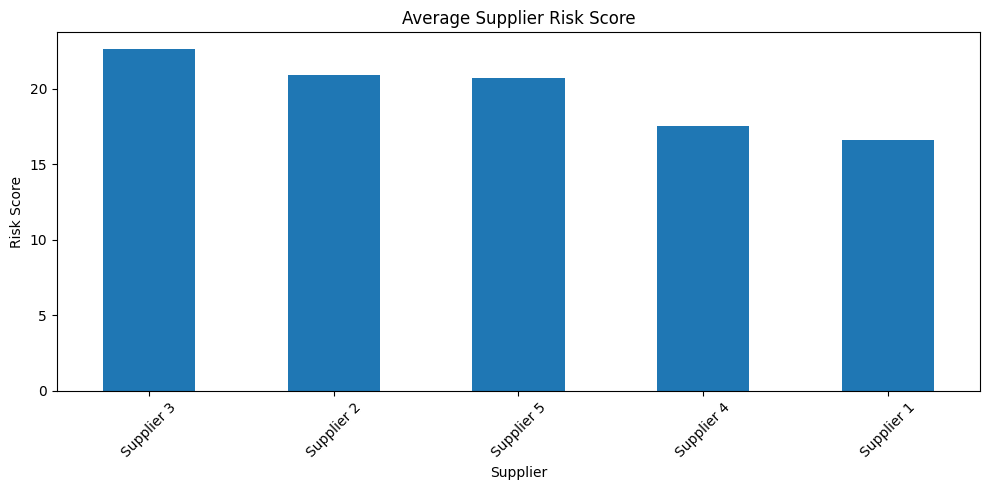

,Supplier_Risk_Score
Supplier_name,
Supplier 3,22.599119
Supplier 2,20.908205
Supplier 5,20.720964
Supplier 4,17.559620
Supplier 1,16.581407


In [14]:
if "Supplier_name" in df.columns and "Supplier_Risk_Score" in df.columns:
    supplier_risk = df.groupby("Supplier_name")["Supplier_Risk_Score"].mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    supplier_risk.plot(kind="bar")
    plt.title("Average Supplier Risk Score")
    plt.xlabel("Supplier")
    plt.ylabel("Risk Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(supplier_risk)

2.8 Correlation Matrix

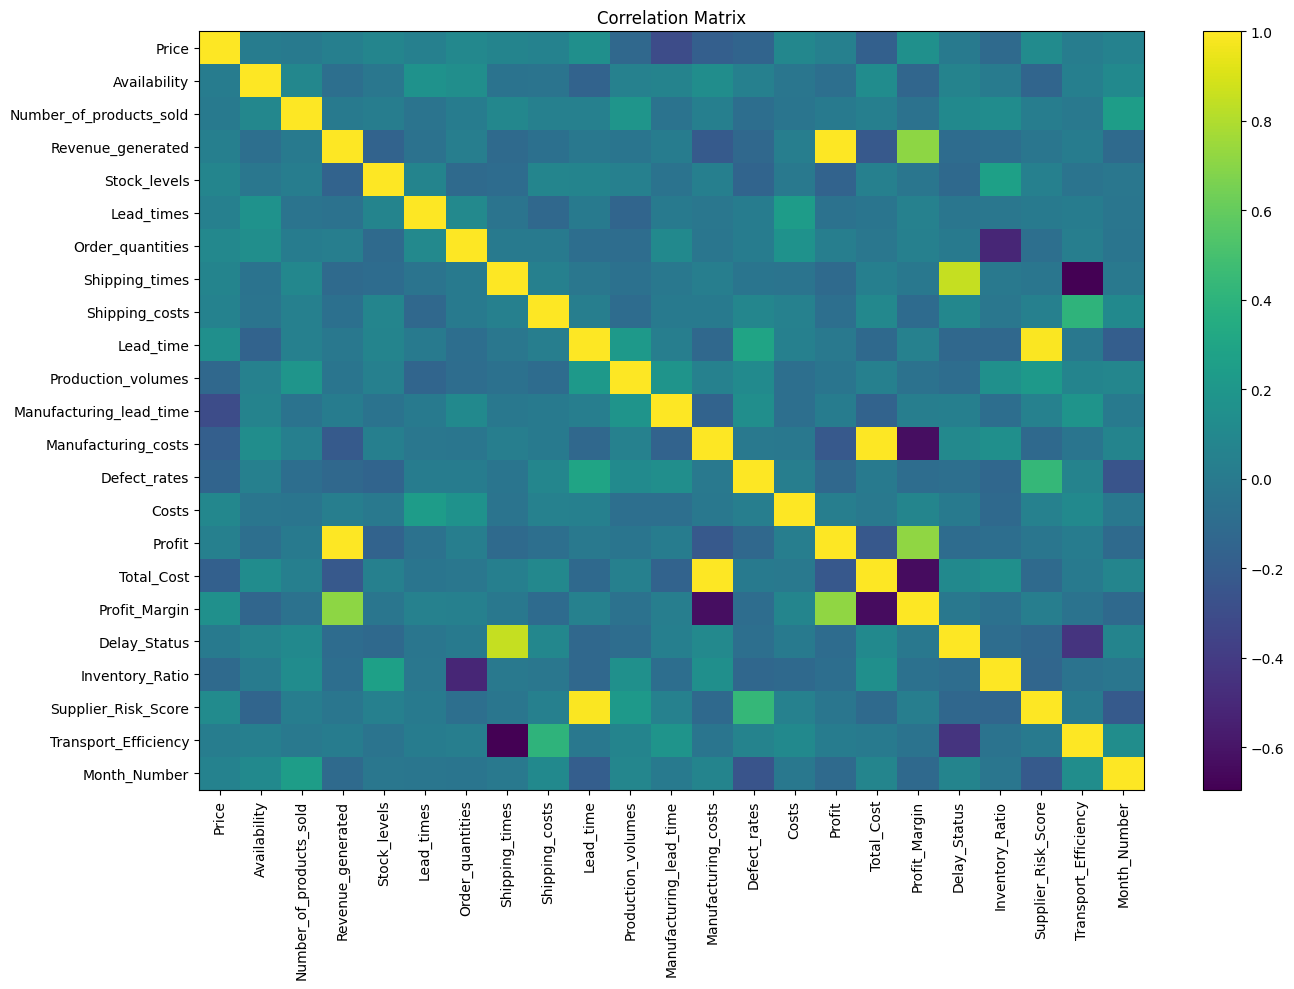

,Price,Availability,Number_of_products_sold,Revenue_generated,Stock_levels,Lead_times,Order_quantities,Shipping_times,Shipping_costs,Lead_time,...,Defect_rates,Costs,Profit,Total_Cost,Profit_Margin,Delay_Status,Inventory_Ratio,Supplier_Risk_Score,Transport_Efficiency,Month_Number
Price,1.000000,0.019083,0.005739,0.038424,0.078261,0.044855,0.095819,0.071942,0.058543,0.152185,...,-0.147247,0.088501,0.040224,-0.177928,0.155499,0.003728,-0.111776,0.120524,0.021805,0.052941
Availability,0.019083,1.000000,0.087496,-0.075170,-0.025900,0.170439,0.143769,-0.051377,-0.044179,-0.156669,...,0.040626,-0.027315,-0.076373,0.129997,-0.137274,0.063667,0.008242,-0.141353,0.036591,0.107156
Number_of_products_sold,0.005739,0.087496,1.000000,-0.001641,0.022189,-0.046419,0.015992,0.087315,0.044285,0.041230,...,-0.082726,-0.036951,-0.002043,0.038155,-0.056042,0.106357,0.129692,0.025983,-0.012368,0.248112
Revenue_generated,0.038424,-0.075170,-0.001641,1.000000,-0.158480,-0.057296,0.029422,-0.109211,-0.072892,-0.014178,...,-0.125335,0.027252,0.999946,-0.219656,0.712266,-0.096263,-0.081774,-0.032881,0.015420,-0.110339
Stock_levels,0.078261,-0.025900,0.022189,-0.158480,1.000000,0.072571,-0.111455,-0.094883,0.072907,0.067880,...,-0.149478,-0.012088,-0.158523,0.039726,-0.029539,-0.115670,0.268719,0.040709,-0.041411,-0.021381
Lead_times,0.044855,0.170439,-0.046419,-0.057296,0.072571,1.000000,0.105459,-0.045156,-0.120746,-0.002818,...,0.015681,0.243686,-0.056784,-0.035320,0.048921,-0.027779,-0.020460,-0.000214,0.014872,-0.033090
Order_quantities,0.095819,0.143769,0.015992,0.029422,-0.111455,0.105459,1.000000,-0.002561,0.004261,-0.086189,...,0.018986,0.167306,0.029631,-0.026270,0.039703,-0.004767,-0.512334,-0.078287,0.030772,-0.037153
Shipping_times,0.071942,-0.051377,0.087315,-0.109211,-0.094883,-0.045156,-0.002561,1.000000,0.045108,-0.022214,...,-0.036673,-0.045541,-0.109302,0.033102,-0.019544,0.848196,-0.010413,-0.026650,-0.695548,-0.007953
Shipping_costs,0.058543,-0.044179,0.044285,-0.072892,0.072907,-0.120746,0.004261,0.045108,1.000000,0.029680,...,0.083139,0.051671,-0.073749,0.097006,-0.106016,0.091368,-0.024246,0.040923,0.404842,0.106019
Lead_time,0.152185,-0.156669,0.041230,-0.014178,0.067880,-0.002818,-0.086189,-0.022214,0.029680,1.000000,...,0.297099,0.045219,-0.012882,-0.118724,0.049283,-0.124652,-0.120049,0.988884,-0.016876,-0.186043


In [15]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(14, 10))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

    display(corr)

2.9 Outlier Detection

Outlier summary:


,Column,Outlier_Count,Lower_Limit,Upper_Limit
0,Price,0,-66.802784,163.598835
1,Availability,0,-55.625000,153.375000
2,Number_of_products_sold,0,-595.750000,1484.250000
3,Revenue_generated,0,-5348.847503,16415.671575
4,Stock_levels,0,-67.625000,157.375000
5,Lead_times,0,-16.000000,48.000000
6,Order_quantities,0,-41.875000,139.125000
7,Shipping_times,0,-2.625000,14.375000
8,Shipping_costs,0,-2.551923,13.693866
9,Lead_time,0,-12.500000,47.500000


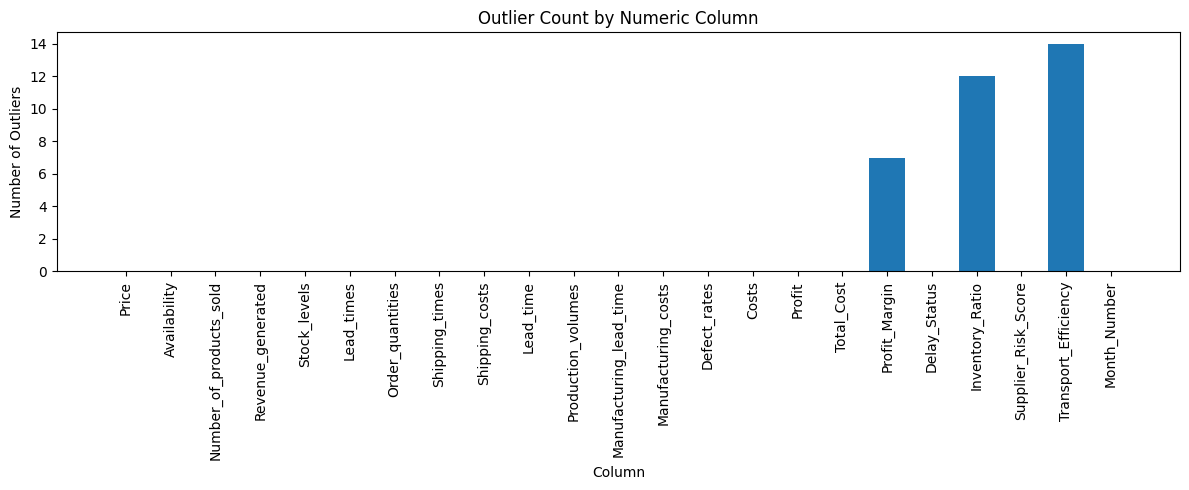

In [16]:
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append([col, len(outliers), lower, upper])

outlier_df = pd.DataFrame(outlier_summary, columns=["Column", "Outlier_Count", "Lower_Limit", "Upper_Limit"])

print("Outlier summary:")
display(outlier_df)

plt.figure(figsize=(12, 5))
plt.bar(outlier_df["Column"], outlier_df["Outlier_Count"])
plt.title("Outlier Count by Numeric Column")
plt.xlabel("Column")
plt.ylabel("Number of Outliers")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

TASK 3 — DEMAND FORECASTING MODULE


TASK 3 — DEMAND FORECASTING MODULE
Demand forecasting model results:


,Model,MAE,RMSE,R2_Score
0,Linear Regression,274.902221,329.458911,-0.137393
1,Random Forest Regressor,277.356000,331.320994,-0.150287


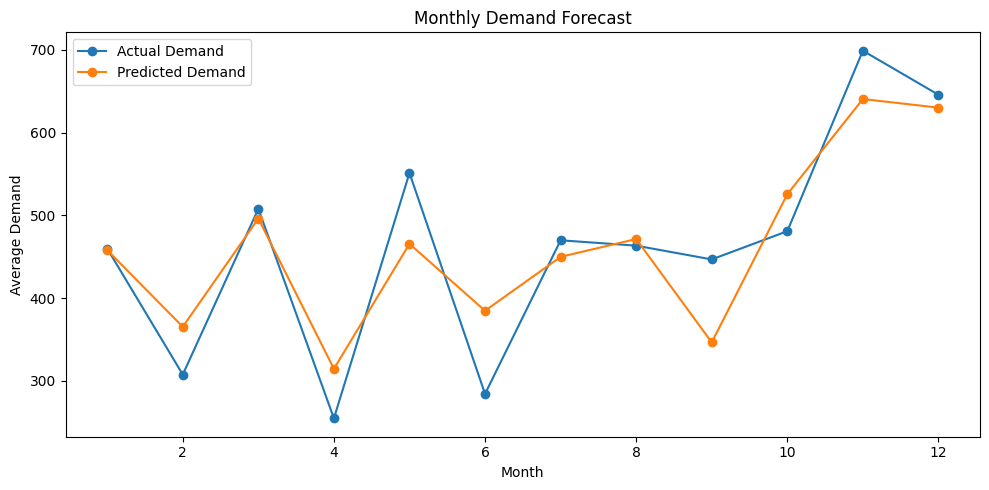

,Month_Number,Actual_Average_Demand,Predicted_Average_Demand
0,1,459.888889,458.021667
1,2,307.555556,365.292222
2,3,507.888889,496.174444
3,4,254.666667,314.511111
4,5,551.250000,465.566250
5,6,284.250000,384.699375
6,7,469.875000,449.845000
7,8,463.375000,471.381250
8,9,446.750000,346.481875
9,10,480.875000,525.565625


In [17]:
print("\nTASK 3 — DEMAND FORECASTING MODULE")

# Target: Number_of_products_sold

if "Number_of_products_sold" in df.columns:

    forecast_df = df.copy()

    # Select useful features
    possible_features = [
        "Price",
        "Availability",
        "Stock_levels",
        "Lead_times",
        "Order_quantities",
        "Shipping_times",
        "Shipping_costs",
        "Manufacturing_costs",
        "Defect_rates",
        "Month_Number"
    ]

    demand_features = []
    for col in possible_features:
        if col in forecast_df.columns:
            demand_features.append(col)

    X = forecast_df[demand_features]
    y = forecast_df["Number_of_products_sold"]

    X = X.fillna(0)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_pred = lr_model.predict(X_test)

    # Random Forest Regressor
    rf_regressor = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
    rf_regressor.fit(X_train, y_train)
    rf_pred = rf_regressor.predict(X_test)

    # Evaluation function
    def evaluate_regression_model(model_name, y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        result = {
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2_Score": r2
        }

        return result

    regression_results = []
    regression_results.append(evaluate_regression_model("Linear Regression", y_test, lr_pred))
    regression_results.append(evaluate_regression_model("Random Forest Regressor", y_test, rf_pred))

    regression_results_df = pd.DataFrame(regression_results)

    print("Demand forecasting model results:")
    display(regression_results_df)

    # Choose Random Forest for final prediction
    forecast_df["Predicted_Demand"] = rf_regressor.predict(X)

    # Future monthly forecast
    monthly_forecast = forecast_df.groupby("Month_Number").agg({
        "Number_of_products_sold": "mean",
        "Predicted_Demand": "mean"
    }).reset_index()

    monthly_forecast.columns = ["Month_Number", "Actual_Average_Demand", "Predicted_Average_Demand"]

    plt.figure(figsize=(10, 5))
    plt.plot(monthly_forecast["Month_Number"], monthly_forecast["Actual_Average_Demand"], marker="o", label="Actual Demand")
    plt.plot(monthly_forecast["Month_Number"], monthly_forecast["Predicted_Average_Demand"], marker="o", label="Predicted Demand")
    plt.title("Monthly Demand Forecast")
    plt.xlabel("Month")
    plt.ylabel("Average Demand")
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(monthly_forecast)

    # Future inventory requirement
    if "Stock_levels" in forecast_df.columns:
        forecast_df["Future_Inventory_Requirement"] = forecast_df["Predicted_Demand"] - forecast_df["Stock_levels"]
        forecast_df["Future_Inventory_Requirement"] = forecast_df["Future_Inventory_Requirement"].apply(lambda x: max(x, 0))
    else:
        forecast_df["Future_Inventory_Requirement"] = forecast_df["Predicted_Demand"]

    demand_output = forecast_df[
        ["SKU", "Product_type", "Month_Number", "Number_of_products_sold", "Predicted_Demand", "Future_Inventory_Requirement"]
    ] if "SKU" in forecast_df.columns and "Product_type" in forecast_df.columns else forecast_df

    demand_output.to_csv("demand_forecast_results.csv", index=False)

else:
    print("Number_of_products_sold column not found. Demand forecasting skipped.")

TASK 4 — DELIVERY DELAY PREDICTION MODULE


TASK 4 — DELIVERY DELAY PREDICTION MODULE
Delivery delay prediction model results:


,Model,Accuracy
0,Logistic Regression,0.95
1,Random Forest Classifier,1.00


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



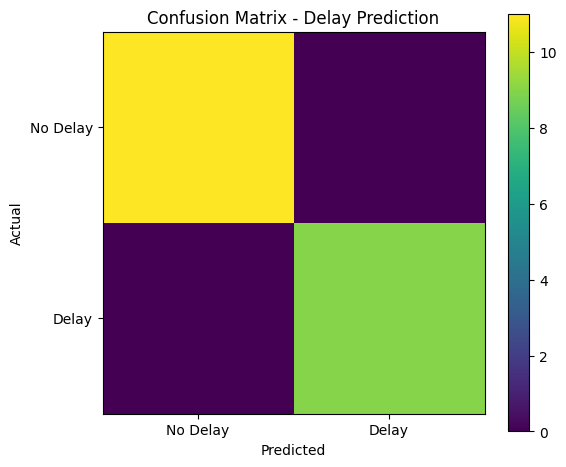

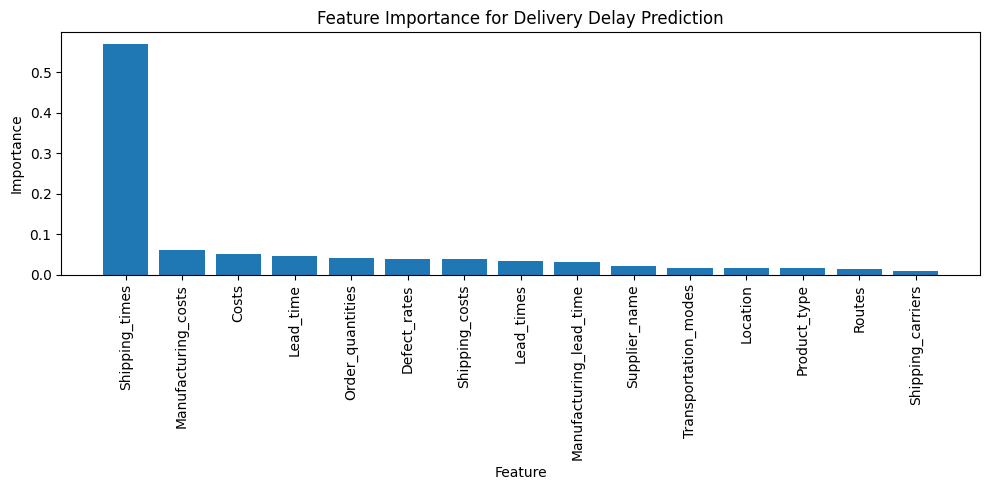

,Feature,Importance
0,Shipping_times,0.569457
6,Manufacturing_costs,0.060661
7,Costs,0.051010
3,Lead_time,0.045487
4,Order_quantities,0.040380
8,Defect_rates,0.039704
1,Shipping_costs,0.038098
2,Lead_times,0.033666
5,Manufacturing_lead_time,0.030075
11,Supplier_name,0.020037


High-risk routes:


,Routes,Delay_Probability,Delay_Status
0,Route A,0.492791,0.511628
1,Route B,0.477432,0.459459
2,Route C,0.414500,0.400000


In [18]:
print("\nTASK 4 — DELIVERY DELAY PREDICTION MODULE")

if "Delay_Status" in df.columns:

    delay_df = df.copy()

    # Features for delay prediction
    delay_possible_features = [
        "Shipping_times",
        "Shipping_costs",
        "Lead_times",
        "Lead_time",
        "Order_quantities",
        "Manufacturing_lead_time",
        "Manufacturing_costs",
        "Costs",
        "Defect_rates",
        "Product_type",
        "Shipping_carriers",
        "Supplier_name",
        "Location",
        "Transportation_modes",
        "Routes"
    ]

    delay_features = []
    for col in delay_possible_features:
        if col in delay_df.columns:
            delay_features.append(col)

    model_df = delay_df[delay_features + ["Delay_Status"]].copy()

    # Encode categorical columns
    encoders = {}
    for col in model_df.columns:
        if model_df[col].dtype == "object" or str(model_df[col].dtype) == "category":
            le = LabelEncoder()
            model_df[col] = le.fit_transform(model_df[col].astype(str))
            encoders[col] = le

    X_delay = model_df.drop("Delay_Status", axis=1)
    y_delay = model_df["Delay_Status"]

    X_train, X_test, y_train, y_test = train_test_split(
        X_delay,
        y_delay,
        test_size=0.2,
        random_state=42,
        stratify=y_delay
    )

    # Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    logistic_model = LogisticRegression(max_iter=1000)
    logistic_model.fit(X_train_scaled, y_train)
    logistic_pred = logistic_model.predict(X_test_scaled)

    # Random Forest Classifier
    rf_classifier = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    rf_classifier.fit(X_train, y_train)
    rf_pred = rf_classifier.predict(X_test)

    # Evaluation
    logistic_accuracy = accuracy_score(y_test, logistic_pred)
    rf_accuracy = accuracy_score(y_test, rf_pred)

    classification_results_df = pd.DataFrame({
        "Model": ["Logistic Regression", "Random Forest Classifier"],
        "Accuracy": [logistic_accuracy, rf_accuracy]
    })

    print("Delivery delay prediction model results:")
    display(classification_results_df)

    print("Random Forest Classification Report:")
    print(classification_report(y_test, rf_pred))

    cm = confusion_matrix(y_test, rf_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title("Confusion Matrix - Delay Prediction")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    plt.xticks([0, 1], ["No Delay", "Delay"])
    plt.yticks([0, 1], ["No Delay", "Delay"])
    plt.tight_layout()
    plt.show()

    # Delay probability
    delay_df["Delay_Probability"] = rf_classifier.predict_proba(X_delay)[:, 1]
    delay_df["Delay_Risk_Level"] = pd.cut(
        delay_df["Delay_Probability"],
        bins=[0, 0.33, 0.66, 1],
        labels=["Low Risk", "Medium Risk", "High Risk"]
    )

    # Feature importance
    feature_importance_df = pd.DataFrame({
        "Feature": X_delay.columns,
        "Importance": rf_classifier.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10, 5))
    plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
    plt.title("Feature Importance for Delivery Delay Prediction")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    display(feature_importance_df)

    # High-risk routes
    if "Routes" in delay_df.columns:
        high_risk_routes = delay_df.groupby("Routes").agg({
            "Delay_Probability": "mean",
            "Delay_Status": "mean"
        }).reset_index().sort_values(by="Delay_Probability", ascending=False)

        print("High-risk routes:")
        display(high_risk_routes)

        high_risk_routes.to_csv("high_risk_routes.csv", index=False)

    delay_output_cols = []
    for col in ["SKU", "Product_type", "Shipping_carriers", "Transportation_modes", "Routes", "Location"]:
        if col in delay_df.columns:
            delay_output_cols.append(col)

    delay_output_cols = delay_output_cols + ["Delay_Status", "Delay_Probability", "Delay_Risk_Level"]

    delay_df[delay_output_cols].to_csv("delivery_delay_prediction_results.csv", index=False)

else:
    print("Delay_Status column not found. Delay prediction skipped.")

TASK 5 — INVENTORY OPTIMIZATION MODULE

In [19]:
print("\nTASK 5 — INVENTORY OPTIMIZATION MODULE")

inventory_df = df.copy()


TASK 5 — INVENTORY OPTIMIZATION MODULE


5.1 ABC Analysis

ABC Analysis:


,SKU,Product_type,Revenue_generated,Number_of_products_sold,Stock_levels,Order_quantities,Revenue_Share,Cumulative_Revenue_Share,ABC_Category
51,SKU51,haircare,9866.465458,154,100,52,0.017082,0.017082,A
38,SKU38,cosmetics,9692.318040,705,69,88,0.016780,0.033862,A
31,SKU31,skincare,9655.135103,168,6,44,0.016716,0.050578,A
90,SKU90,skincare,9592.633570,320,66,96,0.016608,0.067185,A
2,SKU2,haircare,9577.749626,8,1,88,0.016582,0.083767,A
32,SKU32,skincare,9571.550487,781,89,64,0.016571,0.100338,A
67,SKU67,skincare,9473.798033,513,12,71,0.016402,0.116740,A
88,SKU88,cosmetics,9444.742033,737,60,85,0.016352,0.133092,A
52,SKU52,skincare,9435.762609,820,64,11,0.016336,0.149428,A
18,SKU18,haircare,9364.673505,620,10,46,0.016213,0.165641,A


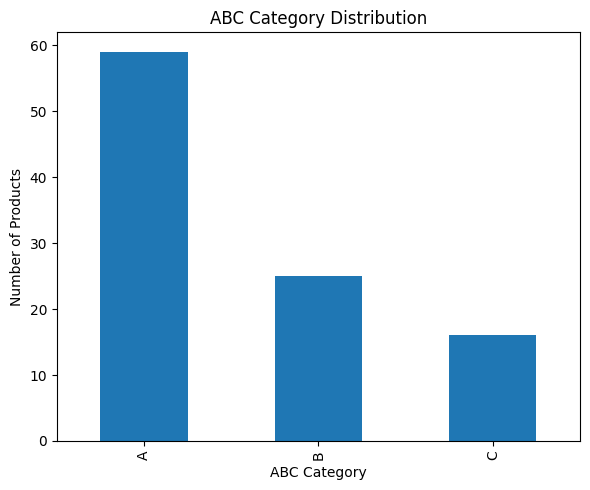

In [20]:
if "Revenue_generated" in inventory_df.columns:

    abc_cols = []
    for col in ["SKU", "Product_type", "Revenue_generated", "Number_of_products_sold", "Stock_levels", "Order_quantities"]:
        if col in inventory_df.columns:
            abc_cols.append(col)

    abc_df = inventory_df[abc_cols].copy()
    abc_df = abc_df.sort_values(by="Revenue_generated", ascending=False)

    total_revenue = abc_df["Revenue_generated"].sum()
    abc_df["Revenue_Share"] = abc_df["Revenue_generated"] / total_revenue
    abc_df["Cumulative_Revenue_Share"] = abc_df["Revenue_Share"].cumsum()

    def abc_category(value):
        if value <= 0.80:
            return "A"
        elif value <= 0.95:
            return "B"
        else:
            return "C"

    abc_df["ABC_Category"] = abc_df["Cumulative_Revenue_Share"].apply(abc_category)

    print("ABC Analysis:")
    display(abc_df.head(20))

    abc_counts = abc_df["ABC_Category"].value_counts()

    plt.figure(figsize=(6, 5))
    abc_counts.plot(kind="bar")
    plt.title("ABC Category Distribution")
    plt.xlabel("ABC Category")
    plt.ylabel("Number of Products")
    plt.tight_layout()
    plt.show()

else:
    print("Revenue_generated column not found. ABC Analysis skipped.")
    abc_df = inventory_df.copy()
    abc_df["ABC_Category"] = "Unknown"

5.2 K-Means Clustering

K-Means Silhouette Score: 0.14393146322741557


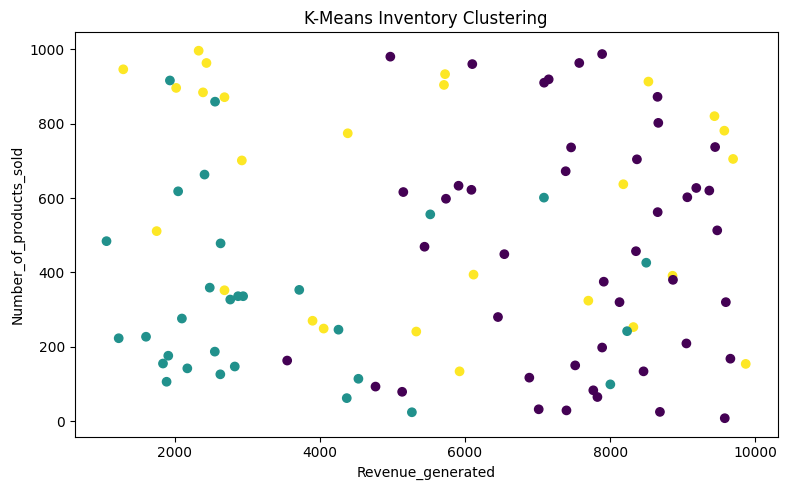

Inventory cluster summary:


,Revenue_generated,Number_of_products_sold,Stock_levels,Order_quantities,Lead_times,Shipping_costs
Inventory_Cluster,,,,,,
0,7541.614610,459.954545,26.772727,57.863636,18.227273,5.139800
1,3465.292241,328.800000,67.500000,45.200000,21.200000,5.098565
2,5454.423411,615.269231,60.538462,39.230769,6.076923,6.757952


In [21]:
cluster_features = []

for col in ["Revenue_generated", "Number_of_products_sold", "Stock_levels", "Order_quantities", "Lead_times", "Shipping_costs"]:
    if col in inventory_df.columns:
        cluster_features.append(col)

if len(cluster_features) >= 2:

    cluster_data = inventory_df[cluster_features].copy()
    cluster_data = cluster_data.fillna(0)

    scaler = StandardScaler()
    scaled_cluster_data = scaler.fit_transform(cluster_data)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    inventory_df["Inventory_Cluster"] = kmeans.fit_predict(scaled_cluster_data)

    silhouette = silhouette_score(scaled_cluster_data, inventory_df["Inventory_Cluster"])
    print("K-Means Silhouette Score:", silhouette)

    plt.figure(figsize=(8, 5))
    plt.scatter(
        inventory_df[cluster_features[0]],
        inventory_df[cluster_features[1]],
        c=inventory_df["Inventory_Cluster"]
    )
    plt.title("K-Means Inventory Clustering")
    plt.xlabel(cluster_features[0])
    plt.ylabel(cluster_features[1])
    plt.tight_layout()
    plt.show()

    cluster_summary = inventory_df.groupby("Inventory_Cluster")[cluster_features].mean()
    print("Inventory cluster summary:")
    display(cluster_summary)

else:
    inventory_df["Inventory_Cluster"] = 0
    print("Not enough numeric features for clustering.")

5.3 Reorder Point Recommendation

In [22]:
if "Number_of_products_sold" in inventory_df.columns and "Lead_times" in inventory_df.columns:
    inventory_df["Daily_Demand"] = inventory_df["Number_of_products_sold"] / 30
    inventory_df["Safety_Stock"] = inventory_df["Daily_Demand"] * 7
    inventory_df["Reorder_Point"] = (inventory_df["Daily_Demand"] * inventory_df["Lead_times"]) + inventory_df["Safety_Stock"]
elif "Number_of_products_sold" in inventory_df.columns:
    inventory_df["Daily_Demand"] = inventory_df["Number_of_products_sold"] / 30
    inventory_df["Safety_Stock"] = inventory_df["Daily_Demand"] * 7
    inventory_df["Reorder_Point"] = inventory_df["Daily_Demand"] * 14
else:
    inventory_df["Daily_Demand"] = 0
    inventory_df["Safety_Stock"] = 0
    inventory_df["Reorder_Point"] = 0

if "Stock_levels" in inventory_df.columns:
    inventory_df["Reorder_Recommendation"] = np.where(
        inventory_df["Stock_levels"] <= inventory_df["Reorder_Point"],
        "Reorder Required",
        "Stock Sufficient"
    )
else:
    inventory_df["Reorder_Recommendation"] = "Unknown"

inventory_output_cols = []

for col in ["SKU", "Product_type", "Stock_levels", "Order_quantities", "Inventory_Status", "Inventory_Cluster"]:
    if col in inventory_df.columns:
        inventory_output_cols.append(col)

inventory_output_cols = inventory_output_cols + ["Daily_Demand", "Safety_Stock", "Reorder_Point", "Reorder_Recommendation"]

inventory_output = inventory_df[inventory_output_cols].copy()

if "SKU" in abc_df.columns:
    inventory_output = inventory_output.merge(
        abc_df[["SKU", "ABC_Category"]],
        on="SKU",
        how="left"
    )
else:
    inventory_output["ABC_Category"] = "Unknown"

print("Inventory optimization output:")
display(inventory_output.head())

inventory_output.to_csv("inventory_optimization_results.csv", index=False)

Inventory optimization output:


,SKU,Product_type,Stock_levels,Order_quantities,Inventory_Status,Inventory_Cluster,Daily_Demand,Safety_Stock,Reorder_Point,Reorder_Recommendation,ABC_Category
0,SKU0,haircare,58,96,Understock,0,26.733333,187.133333,374.266667,Reorder Required,A
1,SKU1,skincare,53,37,Normal,0,24.533333,171.733333,907.733333,Reorder Required,A
2,SKU2,haircare,1,88,Understock,0,0.266667,1.866667,4.533333,Reorder Required,A
3,SKU3,skincare,23,59,Understock,0,2.766667,19.366667,55.333333,Reorder Required,A
4,SKU4,skincare,5,56,Understock,2,29.033333,203.233333,290.333333,Reorder Required,B


TASK 6 — SUPPLIER & TRANSPORTATION ANALYTICS

In [23]:
print("\nTASK 6 — SUPPLIER & TRANSPORTATION ANALYTICS")

supplier_transport_df = df.copy()


TASK 6 — SUPPLIER & TRANSPORTATION ANALYTICS


6.1 Supplier Ranking

Supplier ranking:


,Supplier_name,Lead_time,Defect_rates,Revenue_generated,Manufacturing_costs,Supplier_Risk_Score,Supplier_Rank
0,Supplier 1,14.777778,1.803630,157528.995039,45.254027,16.581407,1
3,Supplier 4,15.222222,2.337397,86468.961799,62.709727,17.559620,2
4,Supplier 5,18.055556,2.665408,110343.463656,44.768243,20.720964,3
1,Supplier 2,18.545455,2.362750,125467.418605,41.622514,20.908205,4
2,Supplier 3,20.133333,2.465786,97795.979638,43.634121,22.599119,5


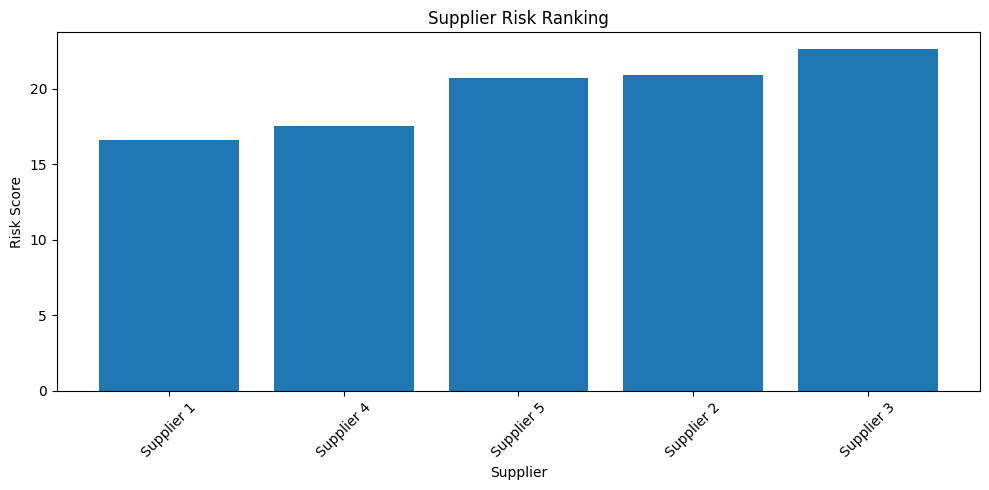

In [24]:
if "Supplier_name" in supplier_transport_df.columns:

    aggregation_dict = {}

    if "Lead_time" in supplier_transport_df.columns:
        aggregation_dict["Lead_time"] = "mean"

    if "Defect_rates" in supplier_transport_df.columns:
        aggregation_dict["Defect_rates"] = "mean"

    if "Revenue_generated" in supplier_transport_df.columns:
        aggregation_dict["Revenue_generated"] = "sum"

    if "Manufacturing_costs" in supplier_transport_df.columns:
        aggregation_dict["Manufacturing_costs"] = "mean"

    if "Supplier_Risk_Score" in supplier_transport_df.columns:
        aggregation_dict["Supplier_Risk_Score"] = "mean"

    supplier_ranking = supplier_transport_df.groupby("Supplier_name").agg(aggregation_dict).reset_index()

    if "Supplier_Risk_Score" in supplier_ranking.columns:
        supplier_ranking = supplier_ranking.sort_values(by="Supplier_Risk_Score", ascending=True)

    supplier_ranking["Supplier_Rank"] = range(1, len(supplier_ranking) + 1)

    print("Supplier ranking:")
    display(supplier_ranking)

    if "Supplier_Risk_Score" in supplier_ranking.columns:
        plt.figure(figsize=(10, 5))
        plt.bar(supplier_ranking["Supplier_name"], supplier_ranking["Supplier_Risk_Score"])
        plt.title("Supplier Risk Ranking")
        plt.xlabel("Supplier")
        plt.ylabel("Risk Score")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    supplier_ranking.to_csv("supplier_ranking.csv", index=False)

else:
    print("Supplier_name column not found.")
    supplier_ranking = pd.DataFrame()

6.2 Transportation Cost and Route Efficiency

Transportation mode summary:


,Transportation_modes,Shipping_costs,Shipping_times,Costs,Delay_Status,Transport_Efficiency
0,Air,6.017839,5.115385,561.712596,0.346154,2.162699
1,Rail,5.469098,6.571429,541.747556,0.535714,1.322881
2,Road,5.542115,4.724138,553.385988,0.344828,1.704649
3,Sea,4.970294,7.117647,417.819148,0.764706,0.756741


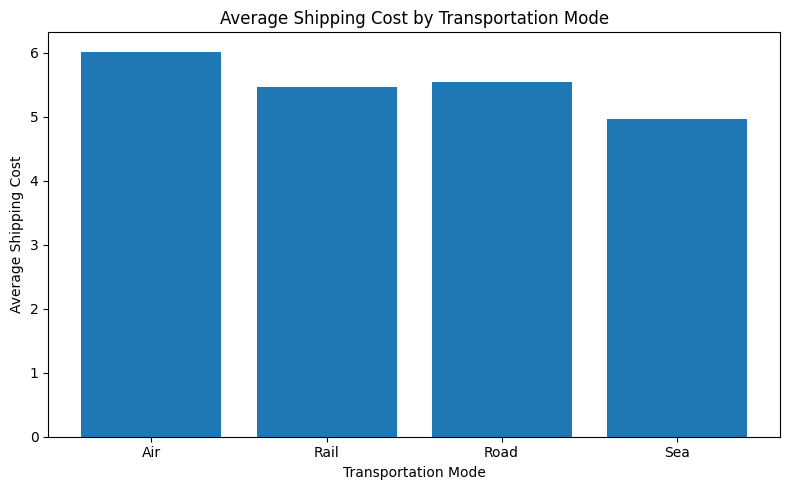

In [25]:
if "Transportation_modes" in supplier_transport_df.columns:

    transport_agg = {}

    if "Shipping_costs" in supplier_transport_df.columns:
        transport_agg["Shipping_costs"] = "mean"

    if "Shipping_times" in supplier_transport_df.columns:
        transport_agg["Shipping_times"] = "mean"

    if "Costs" in supplier_transport_df.columns:
        transport_agg["Costs"] = "mean"

    if "Delay_Status" in supplier_transport_df.columns:
        transport_agg["Delay_Status"] = "mean"

    if "Transport_Efficiency" in supplier_transport_df.columns:
        transport_agg["Transport_Efficiency"] = "mean"

    transport_summary = supplier_transport_df.groupby("Transportation_modes").agg(transport_agg).reset_index()

    print("Transportation mode summary:")
    display(transport_summary)

    if "Shipping_costs" in transport_summary.columns:
        plt.figure(figsize=(8, 5))
        plt.bar(transport_summary["Transportation_modes"], transport_summary["Shipping_costs"])
        plt.title("Average Shipping Cost by Transportation Mode")
        plt.xlabel("Transportation Mode")
        plt.ylabel("Average Shipping Cost")
        plt.tight_layout()
        plt.show()

    transport_summary.to_csv("transportation_summary.csv", index=False)

else:
    print("Transportation_modes column not found.")
    transport_summary = pd.DataFrame()

6.3 Route Bottleneck Identification

Route bottleneck analysis:


,Routes,Shipping_times,Shipping_costs,Delay_Status,Transport_Efficiency
0,Route A,6.023256,5.379699,0.511628,1.499685
1,Route B,5.702703,5.551986,0.459459,1.363592
2,Route C,5.250000,5.903218,0.400000,2.031545


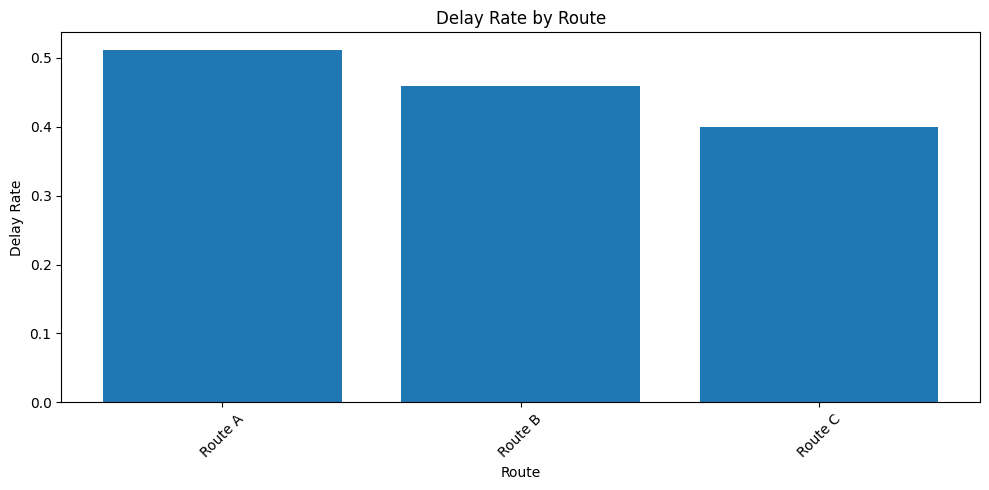

In [26]:
if "Routes" in supplier_transport_df.columns:

    route_agg = {}

    if "Shipping_times" in supplier_transport_df.columns:
        route_agg["Shipping_times"] = "mean"

    if "Shipping_costs" in supplier_transport_df.columns:
        route_agg["Shipping_costs"] = "mean"

    if "Delay_Status" in supplier_transport_df.columns:
        route_agg["Delay_Status"] = "mean"

    if "Transport_Efficiency" in supplier_transport_df.columns:
        route_agg["Transport_Efficiency"] = "mean"

    route_summary = supplier_transport_df.groupby("Routes").agg(route_agg).reset_index()

    if "Delay_Status" in route_summary.columns:
        route_summary = route_summary.sort_values(by="Delay_Status", ascending=False)

    print("Route bottleneck analysis:")
    display(route_summary)

    if "Delay_Status" in route_summary.columns:
        plt.figure(figsize=(10, 5))
        plt.bar(route_summary["Routes"], route_summary["Delay_Status"])
        plt.title("Delay Rate by Route")
        plt.xlabel("Route")
        plt.ylabel("Delay Rate")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    route_summary.to_csv("route_bottleneck_analysis.csv", index=False)

else:
    print("Routes column not found.")
    route_summary = pd.DataFrame()

6.4 Supply Chain Risk Analysis

In [27]:
risk_df = supplier_transport_df.copy()

risk_components = []

if "Delay_Status" in risk_df.columns:
    risk_components.append("Delay_Status")

if "Defect_rates" in risk_df.columns:
    risk_df["Defect_Risk_Normalized"] = risk_df["Defect_rates"] / risk_df["Defect_rates"].max()
    risk_components.append("Defect_Risk_Normalized")

if "Lead_time" in risk_df.columns:
    risk_df["Lead_Time_Risk_Normalized"] = risk_df["Lead_time"] / risk_df["Lead_time"].max()
    risk_components.append("Lead_Time_Risk_Normalized")

if "Shipping_costs" in risk_df.columns:
    risk_df["Shipping_Cost_Risk_Normalized"] = risk_df["Shipping_costs"] / risk_df["Shipping_costs"].max()
    risk_components.append("Shipping_Cost_Risk_Normalized")

if len(risk_components) > 0:
    risk_df["Supply_Chain_Risk_Index"] = risk_df[risk_components].mean(axis=1)
else:
    risk_df["Supply_Chain_Risk_Index"] = 0

risk_df["Risk_Level"] = pd.cut(
    risk_df["Supply_Chain_Risk_Index"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

risk_output_cols = []

for col in ["SKU", "Product_type", "Supplier_name", "Routes", "Transportation_modes", "Location"]:
    if col in risk_df.columns:
        risk_output_cols.append(col)

risk_output_cols = risk_output_cols + ["Supply_Chain_Risk_Index", "Risk_Level"]

risk_output = risk_df[risk_output_cols].copy()

print("Supply chain risk analysis:")
display(risk_output.head())

risk_output.to_csv("supply_chain_risk_analysis.csv", index=False)

Supply chain risk analysis:


,SKU,Product_type,Supplier_name,Routes,Transportation_modes,Location,Supply_Chain_Risk_Index,Risk_Level
0,SKU0,haircare,Supplier 3,Route B,Road,Mumbai,0.327563,Low Risk
1,SKU1,skincare,Supplier 3,Route B,Road,Mumbai,0.681986,High Risk
2,SKU2,haircare,Supplier 1,Route C,Air,Mumbai,0.534632,Medium Risk
3,SKU3,skincare,Supplier 5,Route A,Rail,Kolkata,0.483796,Medium Risk
4,SKU4,skincare,Supplier 1,Route A,Air,Delhi,0.548831,Medium Risk


BUSINESS INSIGHTS

In [28]:
print("\nBUSINESS INSIGHTS")

insights = []

# Insight 1
if "Product_type" in df.columns and "Revenue_generated" in df.columns:
    top_product = df.groupby("Product_type")["Revenue_generated"].sum().idxmax()
    insights.append("The highest revenue is generated by product type: " + str(top_product))

# Insight 2
if "Delay_Status" in df.columns:
    delay_rate = df["Delay_Status"].mean() * 100
    insights.append("The average delivery delay rate is " + str(round(delay_rate, 2)) + "%, which shows the level of logistics risk.")

# Insight 3
if "Inventory_Status" in df.columns:
    understock_count = len(df[df["Inventory_Status"] == "Understock"])
    overstock_count = len(df[df["Inventory_Status"] == "Overstock"])
    insights.append("Inventory analysis found " + str(understock_count) + " understock items and " + str(overstock_count) + " overstock items.")

# Insight 4
if "Supplier_name" in df.columns and "Supplier_Risk_Score" in df.columns:
    riskiest_supplier = df.groupby("Supplier_name")["Supplier_Risk_Score"].mean().idxmax()
    insights.append("The riskiest supplier based on lead time and defect rate is: " + str(riskiest_supplier))

# Insight 5
if "Shipping_carriers" in df.columns and "Shipping_costs" in df.columns:
    expensive_carrier = df.groupby("Shipping_carriers")["Shipping_costs"].mean().idxmax()
    insights.append("The most expensive shipping carrier on average is: " + str(expensive_carrier))

for i, insight in enumerate(insights, start=1):
    print("Insight " + str(i) + ": " + insight)

business_insights_df = pd.DataFrame({
    "Insight_Number": range(1, len(insights) + 1),
    "Business_Insight": insights
})

business_insights_df.to_csv("business_insights.csv", index=False)


BUSINESS INSIGHTS
Insight 1: The highest revenue is generated by product type: skincare
Insight 2: The average delivery delay rate is 47.0%, which shows the level of logistics risk.
Insight 3: Inventory analysis found 48 understock items and 22 overstock items.
Insight 4: The riskiest supplier based on lead time and defect rate is: Supplier 3
Insight 5: The most expensive shipping carrier on average is: Carrier C


EXPORT DATA FOR POWER BI

In [29]:
print("\nEXPORTING DATA FOR POWER BI")

# Main final dataset
df.to_csv("powerbi_main_dataset.csv", index=False)

# Executive summary
executive_summary = {}

if "Revenue_generated" in df.columns:
    executive_summary["Total_Revenue"] = df["Revenue_generated"].sum()
else:
    executive_summary["Total_Revenue"] = 0

if "Profit" in df.columns:
    executive_summary["Total_Profit"] = df["Profit"].sum()
else:
    executive_summary["Total_Profit"] = 0

if "SKU" in df.columns:
    executive_summary["Total_SKUs"] = df["SKU"].nunique()
else:
    executive_summary["Total_SKUs"] = len(df)

if "Delay_Status" in df.columns:
    executive_summary["Delivery_Success_Rate"] = (1 - df["Delay_Status"].mean()) * 100
else:
    executive_summary["Delivery_Success_Rate"] = 0

if "Inventory_Status" in df.columns:
    executive_summary["Understock_Items"] = len(df[df["Inventory_Status"] == "Understock"])
    executive_summary["Overstock_Items"] = len(df[df["Inventory_Status"] == "Overstock"])
else:
    executive_summary["Understock_Items"] = 0
    executive_summary["Overstock_Items"] = 0

executive_summary_df = pd.DataFrame([executive_summary])
display(executive_summary_df)

executive_summary_df.to_csv("executive_summary.csv", index=False)

# Create Excel file for Power BI
with pd.ExcelWriter("logistics_powerbi_export.xlsx") as writer:
    df.to_excel(writer, sheet_name="Main_Data", index=False)
    executive_summary_df.to_excel(writer, sheet_name="Executive_Summary", index=False)
    business_insights_df.to_excel(writer, sheet_name="Business_Insights", index=False)
    outlier_df.to_excel(writer, sheet_name="Outlier_Summary", index=False)

    if "monthly_forecast" in globals():
        monthly_forecast.to_excel(writer, sheet_name="Demand_Forecast", index=False)

    if "regression_results_df" in globals():
        regression_results_df.to_excel(writer, sheet_name="Forecast_Model_Results", index=False)

    if "classification_results_df" in globals():
        classification_results_df.to_excel(writer, sheet_name="Delay_Model_Results", index=False)

    if "feature_importance_df" in globals():
        feature_importance_df.to_excel(writer, sheet_name="Feature_Importance", index=False)

    if "abc_df" in globals():
        abc_df.to_excel(writer, sheet_name="ABC_Analysis", index=False)

    if "inventory_output" in globals():
        inventory_output.to_excel(writer, sheet_name="Inventory_Optimization", index=False)

    if "supplier_ranking" in globals():
        supplier_ranking.to_excel(writer, sheet_name="Supplier_Ranking", index=False)

    if "transport_summary" in globals():
        transport_summary.to_excel(writer, sheet_name="Transport_Summary", index=False)

    if "route_summary" in globals():
        route_summary.to_excel(writer, sheet_name="Route_Bottlenecks", index=False)

    if "risk_output" in globals():
        risk_output.to_excel(writer, sheet_name="Risk_Analysis", index=False)

print("Power BI Excel file created: logistics_powerbi_export.xlsx")


EXPORTING DATA FOR POWER BI


,Total_Revenue,Total_Profit,Total_SKUs,Delivery_Success_Rate,Understock_Items,Overstock_Items
0,577604.818738,572323.334507,100,53.0,48,22


Power BI Excel file created: logistics_powerbi_export.xlsx


FINAL REPORT TEXT OUTPUT

In [30]:
report_text = """
AI-Driven Smart Logistics & Supply Chain Intelligence System

Project Summary:
This project developed an intelligent logistics and supply chain analytics system using Python, machine learning, and Power BI. The dataset was cleaned, analyzed, modeled, and prepared for dashboard development.

Task 1 - Data Cleaning:
The dataset was cleaned by removing duplicates, handling missing values, standardizing column names, converting data types, and creating new calculated columns such as Profit, Total Cost, Delay Status, Inventory Status, Supplier Risk Score, and Transport Efficiency.

Task 2 - Exploratory Data Analysis:
EDA was performed to understand product revenue, sales trends, seasonality, delivery performance, shipping costs, inventory levels, supplier behavior, correlations, and outliers. These insights helped guide the modeling process.

Task 3 - Demand Forecasting:
Linear Regression and Random Forest Regressor were used to predict product demand. Random Forest was selected as the main model because it can capture more complex patterns. The model produced predicted demand and future inventory requirements.

Task 4 - Delivery Delay Prediction:
Logistic Regression and Random Forest Classifier were used to predict delivery delays. The output includes delay probability, delay risk level, feature importance, and high-risk delivery routes.

Task 5 - Inventory Optimization:
ABC Analysis was used to classify products based on revenue importance. K-Means Clustering grouped products by inventory and demand patterns. Reorder points and reorder recommendations were created to identify products that need restocking.

Task 6 - Supplier and Transportation Analytics:
Supplier performance was analyzed using lead time, defect rate, revenue, and supplier risk score. Transportation analysis reviewed shipping costs, shipping times, delay rates, route bottlenecks, and supply chain risks.

Business Insights:
"""

for insight in insights:
    report_text = report_text + "- " + insight + "\n"

report_text = report_text + """
Conclusion:
The project shows how AI and analytics can improve logistics decision-making. The system helps managers forecast demand, reduce delivery delays, optimize inventory, evaluate suppliers, identify transport bottlenecks, and make better strategic decisions using Power BI dashboards.
"""

with open("final_report_text.txt", "w") as file:
    file.write(report_text)

print("Final report text saved as final_report_text.txt")

Final report text saved as final_report_text.txt


DOWNLOAD FILES FROM COLAB

In [31]:
print("\nALL FILES CREATED SUCCESSFULLY")
print("Main files for submission and Power BI:")
print("1. cleaned_supply_chain_data.csv")
print("2. demand_forecast_results.csv")
print("3. delivery_delay_prediction_results.csv")
print("4. inventory_optimization_results.csv")
print("5. supplier_ranking.csv")
print("6. transportation_summary.csv")
print("7. route_bottleneck_analysis.csv")
print("8. supply_chain_risk_analysis.csv")
print("9. logistics_powerbi_export.xlsx")
print("10. final_report_text.txt")

print("\nUse logistics_powerbi_export.xlsx for Power BI dashboard.")


ALL FILES CREATED SUCCESSFULLY
Main files for submission and Power BI:
1. cleaned_supply_chain_data.csv
2. demand_forecast_results.csv
3. delivery_delay_prediction_results.csv
4. inventory_optimization_results.csv
5. supplier_ranking.csv
6. transportation_summary.csv
7. route_bottleneck_analysis.csv
8. supply_chain_risk_analysis.csv
9. logistics_powerbi_export.xlsx
10. final_report_text.txt

Use logistics_powerbi_export.xlsx for Power BI dashboard.
